## 1. Introdução
Este experimento implementa uma Rede de Memória Associativa Bidirecional (BAM) para reconhecer dígitos do dataset MNIST e compara seu desempenho com uma Rede de Hopfield.





Os dados foram carregados do dataset MNIST. Para que as redes associativas funcionem corretamente, os dados precisam ser convertidos para o formato bipolar (valores $1$ e $-1$), onde:1: Representa a presença de informação (pixel ativado).-1: Representa a ausência de informação (fundo).

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from sklearn.datasets import fetch_openml

# --- 1. CARREGAMENTO E PREPARAÇÃO DOS DADOS ---

def carregar_mnist_bipolar(numeros_desejados=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]):
    print("Baixando MNIST... (isso pode demorar um pouco na primeira vez)")
    mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
    X, y = mnist.data, mnist.target.astype(int)

    padroes_treino = []

    for num in numeros_desejados:
        # Pega a primeira ocorrência de cada número desejado
        idx = np.where(y == num)[0][0]
        # Converte para bipolar: pixels > 127 viram 1, o resto vira -1
        img_bipolar = np.where(X[idx] > 127, 1, -1)
        padroes_treino.append(img_bipolar)

    return np.array(padroes_treino)

In [10]:
def carregar_dados_formatados(numeros=[0,1,2,3,4,5,6,7,8,9]):
    #matriz A
    X_bipolar = carregar_mnist_bipolar(numeros_desejados=numeros)

    #cada linha é um vetor de 10 posições (-1 e 1)
    B_labels = np.full((len(numeros), 10), -1)
    for i in range(len(numeros)):
        B_labels[i, i] = 1

    return X_bipolar, B_labels

## 2. Implementação da BAM
A BAM é uma rede  hetero-associativas, isto é, dado um padrão de entrada, podem retornar um padrão de tamanho diferente.Por exemplo: uma imagem de 784 pixels com um rótulo de 10 posições.
- **Treinamento:** Utilizamos a correlação cruzada das matrizes de padrões.
- **Recuperação:** Ocorre um processo bidirecional até a estabilização da energia do sistema.
- A cada iteração sinais são enviados entre as duas camadas até as ativações dos neurônios ficarem constantes.

In [11]:
class RedeBAM:
    def __init__(self, A, B):
        # Treinamento:A memória da rede é construída através do produto tensorial
        #entre os vetores de entrada A e os vetores de saída desejados B
        self.M = np.dot(A.T, B)

    def ativa(self, v):
        # se o valor de entrada v for maior que 0, a saída é 1
        # se for menor que 0, a saída é -1
        # se for exatamente 0, aplicamos uma ativação estocástica
        v_ativado = np.where(v > 0, 1, np.where(v < 0, -1, np.random.choice([1, -1])))
        return v_ativado

    def recuperar(self, padrao_ruidoso, max_iter=20):
      # x inicia como o padrão de entrada que queremos reconhecer
        x = padrao_ruidoso
        h_antigo = 1e6 #Valor arbitrário alto para a primeira comparação
        for i in range(max_iter):
            # X -> Y: projetamos a entrada X na camada de saída Y
            y = self.ativa(np.dot(x, self.M))
            # Cálculo da Energia (Entropia)
            h = -np.dot(np.dot(x, self.M), y)
            # Y -> X: projetamos a saída Y de volta para a camada de entrada X
            x = self.ativa(np.dot(self.M, y))

            if abs(h - h_antigo) == 0: break #se a energia parar de mudar (delta = 0),
            # significa que a rede estabilizou em um atrator.
            h_antigo = h

        # retorna o par de vetores estabilizados (imagem recuperada e rótulo correspondente)
        return x, y

## 3. Implementação da Rede de Hopfield

Diferente da BAM, a Rede de Hopfield é autoassociativa. A resposta da rede não depende apenas dos padrões de entrada, mas também do estado em que a rede se encontra.Tem a habilidade de recuperar um padrão armazenado, dado um conjunto razoável de informações daquele padrão.
- **Estrutura:** A matriz de pesos $W$ é quadrada ($784 \times 784$ no caso dos dados MNIST).


In [12]:
class RedeHopfield:
    def __init__(self, A):
        # N = nro de neurônios, que é o tamanho do vetor de entrada (784)
        N = A.shape[1]


        # multiplicamos o padrão por ele mesmo (A.T @ A)
        self.W = np.dot(A.T, A).astype(float)

        # a diagonal principal deve ser zerada.
        # evita que um neurônio influencie a si mesmo diretamente)
        np.fill_diagonal(self.W, 0)

        # normalização dos pesos
        self.W /= N

    def recuperar(self, padrao, steps=5):
        s = padrao.copy()

        #O processo iterativo acontece até que não ocorram mais mudanças nos estados dos neurônios
        for _ in range(steps):
            #a nova ativação do neurônio é calculada pelo sinal do produto (W @ s)
            # Se o resultado for >= 0, o neurônio assume 1; caso contrário, -1
            s = np.where(np.dot(self.W, s) >= 0, 1, -1)

        #retorna o padrão
        return s

In [13]:
def adicionar_ruido(padrao, nivel):
    ruidoso = padrao.copy()
    mask = np.random.choice([True, False], size=padrao.shape, p=[nivel, 1-nivel])
    ruidoso[mask] *= -1
    return ruidoso


Baixando MNIST... (isso pode demorar um pouco na primeira vez)


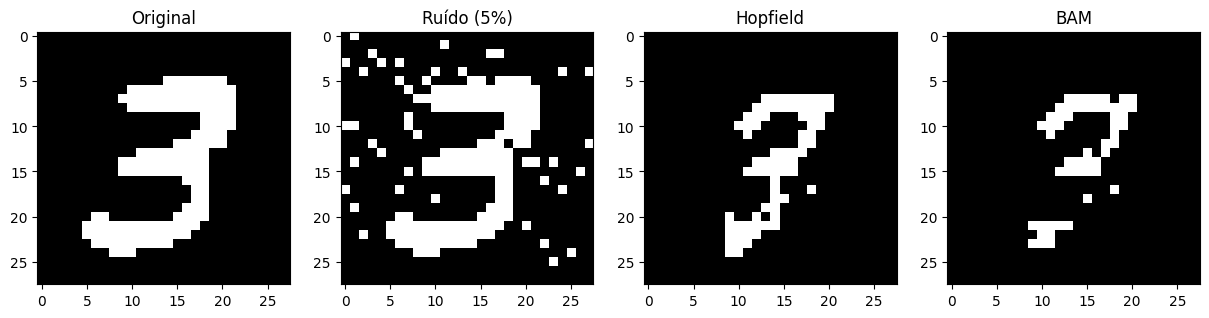

In [14]:
A, B = carregar_dados_formatados()
bam = RedeBAM(A, B)
hopfield = RedeHopfield(A)

nivel_ruido = 0.05 # 10% de variação
digito_idx = 3

original = A[digito_idx]
ruidoso = adicionar_ruido(original, nivel_ruido)

# Testando BAM
rec_A_bam, rec_B_bam = bam.recuperar(ruidoso)

# Testando Hopfield
rec_A_hop = hopfield.recuperar(ruidoso)
digito_reconhecido = np.argmax(rec_B_bam)

# --- VISUALIZAÇÃO ---
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(original.reshape(28,28), cmap='gray'); axes[0].set_title("Original")
axes[1].imshow(ruidoso.reshape(28,28), cmap='gray'); axes[1].set_title(f"Ruído ({int(nivel_ruido*100)}%)")
axes[2].imshow(rec_A_hop.reshape(28,28), cmap='gray'); axes[2].set_title("Hopfield")
axes[3].imshow(rec_A_bam.reshape(28,28), cmap='gray'); axes[3].set_title("BAM")
plt.show()


## 4. Análise dos Experimentos e Comparação
Ao executar os testes com ruído, foi observado os seguintes pontos:

### Capacidade de Armazenamento
As redes associativas possuem uma capacidade limitada. Se tentarmos armazenar os 10 dígitos do MNIST simultaneamente:

- A BAM pode apresentar erros devido à alta dimensionalidade dos dados e à sobreposição de padrões (muitos dígitos compartilham pixels na mesma posição).

- A Hopfield tende a ser mais robusta para recuperar a imagem, mas exige muito mais memória para armazenar a matriz de pesos.

###Sensibilidade ao Ruído:
- A Rede de Hopfield costuma ser mais resiliente para recuperar a imagem visual, enquanto a BAM é muito útil para identificar a qual classe o dígito pertence.

- Observou-se ainda que a rede BAM, embora corretamente implementada, apresenta dificuldades com o dataset MNIST. Isso ocorre, porque quando os padrões de entrada (A) têm muita sobreposição, o produto tensorial acaba gerando uma matriz "saturada", onde o padrão mais frequente ou mais forte (neste caso, o dígito 0) acaba dominando todos os outros.